In [9]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Configuração dos dados de treino: horas de estudo vs resultado (0=Reprovado, 1=Aprovado).
X = np.array([[1], [2], [2], [3], [3], [4], [5], [6], [6], [7], [8], [9]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# Instanciação e ajuste do modelo de Regressão Logística aos dados.
model = LogisticRegression()
model.fit(X, y)

# Estimativa da probabilidade de cada classe para um aluno que estudou 5 horas.
prob = model.predict_proba([[5]])
# Exemplo de saída: [[0.34430187 0.65569813]]
#                     |          |
# probabilidade de: reprovado   aprovado

probAprovado = prob[0][1]
# Extração da probabilidade de sucesso (classe 1) da matriz de resultados.

print(f"Probabilidade de aprovação com 5h: {probAprovado:.2%}")
# Resultado esperado: ~65,56%

# Predição da categoria final (Aprovado ou Reprovado) baseada no limiar padrão (0.5).
classe = model.predict([[5]])
print(classe[0])
# Saída 1 indica 'Aprovado'

print(f"Classificação: {'Aprovado' if classe == 1 else 'Reprovado'}")


Probabilidade de aprovação com 5h: 65.57%
1
Classificação: Aprovado


TPR: [0.    0.025 0.5   0.5   0.675 0.675 0.75  0.75  0.8   0.8   0.825 0.825
 0.85  0.85  0.875 0.875 0.925 0.925 0.95  0.95  0.975 0.975 1.    1.   ] - FPR: [0.      0.      0.      0.00625 0.00625 0.01875 0.01875 0.025   0.025
 0.0625  0.0625  0.06875 0.06875 0.075   0.075   0.0875  0.0875  0.11875
 0.11875 0.21875 0.21875 0.41875 0.41875 1.     ] - Thresholds: [       inf 0.98071945 0.81114122 0.8014732  0.65284579 0.64637695
 0.60335415 0.57857163 0.57316173 0.51990928 0.51802389 0.50989664
 0.50743364 0.50312308 0.48978344 0.48458976 0.48123381 0.45950641
 0.45847878 0.37344885 0.37202414 0.29236183 0.28643267 0.03439862]
AUC: 0.97


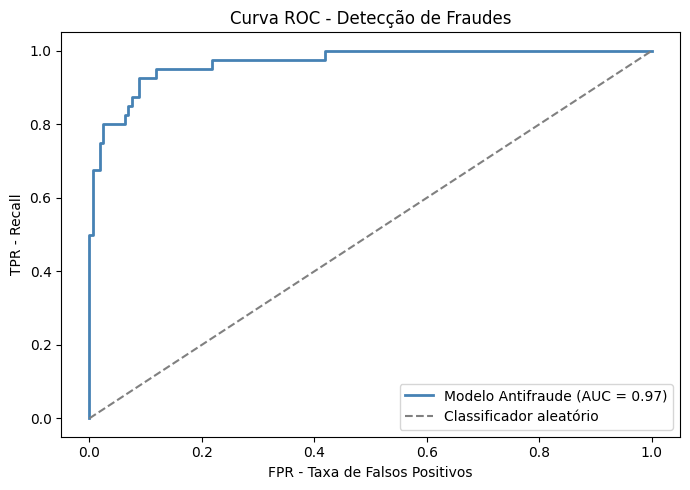

Threshold=inf -> FPR=0.00, TPR=0.00
Threshold=0.98 -> FPR=0.00, TPR=0.03
Threshold=0.81 -> FPR=0.00, TPR=0.50
Threshold=0.80 -> FPR=0.01, TPR=0.50
Threshold=0.65 -> FPR=0.01, TPR=0.68
Threshold=0.65 -> FPR=0.02, TPR=0.68
Threshold=0.60 -> FPR=0.02, TPR=0.75
Threshold=0.58 -> FPR=0.03, TPR=0.75
Threshold=0.57 -> FPR=0.03, TPR=0.80
Threshold=0.52 -> FPR=0.06, TPR=0.80
Threshold=0.52 -> FPR=0.06, TPR=0.82
Threshold=0.51 -> FPR=0.07, TPR=0.82
Threshold=0.51 -> FPR=0.07, TPR=0.85
Threshold=0.50 -> FPR=0.07, TPR=0.85
Threshold=0.49 -> FPR=0.07, TPR=0.88
Threshold=0.48 -> FPR=0.09, TPR=0.88
Threshold=0.48 -> FPR=0.09, TPR=0.93
Threshold=0.46 -> FPR=0.12, TPR=0.93
Threshold=0.46 -> FPR=0.12, TPR=0.95
Threshold=0.37 -> FPR=0.22, TPR=0.95
Threshold=0.37 -> FPR=0.22, TPR=0.97
Threshold=0.29 -> FPR=0.42, TPR=0.97
Threshold=0.29 -> FPR=0.42, TPR=1.00
Threshold=0.03 -> FPR=1.00, TPR=1.00


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Geração de um dataset sintético com 200 transações (80% legítimas / 20% fraudes).
n_legit = 160
n_fraud = 40

y_real = np.array([0] * n_legit + [1] * n_fraud)

# Simulação de scores de um modelo preditivo com ruído e sobreposição entre classes.
# Atribuição de scores baixos para transações legítimas.
proba_legit = np.clip(np.random.beta(2, 5, n_legit), 0, 1)
# Atribuição de scores altos para fraudes.
proba_fraud = np.clip(np.random.beta(5, 2, n_fraud), 0, 1)

y_proba = np.concatenate([proba_legit, proba_fraud])

fpr, tpr, thresholds = roc_curve(y_real, y_proba)
print(f"TPR: {tpr} - FPR: {fpr} - Thresholds: {thresholds}")

auc = roc_auc_score(y_real, y_proba)
print(f"AUC: {auc:.2f}")

# Geração do gráfico da Curva ROC para avaliar a performance do modelo antifraude.
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"Modelo Antifraude (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Classificador aleatório")
plt.xlabel("FPR - Taxa de Falsos Positivos")
plt.ylabel("TPR - Recall")
plt.title("Curva ROC - Detecção de Fraudes")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# COMENTÁRIO: O que a Curva ROC Representa:
# - Eixo X (FPR): Taxa de Falsos Positivos - proporção de transações legítimas incorretamente classificadas como fraude
# - Eixo Y (TPR): Taxa de Verdadeiros Positivos (Recall) - proporção de fraudes corretamente detectadas
# 
# Interpretação dos Resultados:
# - AUC = 0.97: Excelente performance (próximo de 1.0)
# - Quanto mais próxima a curva estiver do canto superior esquerdo, melhor o modelo
# - A linha diagonal cinza representa um classificador aleatório (AUC = 0.5)
# 
# Trade-offs entre thresholds:
# - Thresholds altos: Menos falsos positivos, mas também menos detecções
# - Thresholds baixos: Mais detecções, mas também mais falsos positivos

# Detalhamento dos trade-offs entre falsos positivos e sensibilidade para cada threshold.
for f, t, thresh in zip(fpr, tpr, thresholds):
    print(f"Threshold={thresh:.2f} -> FPR={f:.2f}, TPR={t:.2f}")